In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
from scipy.special import softmax
import seaborn as sns
from collections import defaultdict
import ipyvolume as ipv
import os
from pyreadr import read_r
from scipy.spatial.distance import pdist, squareform
from terminal_pareto import ParetoFront
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300



t_threshold = 255
ts_df = pd.read_csv("./data/embryo1/tracks.txt", sep="\t")
ts_df = ts_df.loc[ts_df["t"] <= t_threshold]
all_xyz_map = {}
cell_names = ts_df["name"].unique()
valid_cell_names = []
for name in cell_names:
    time_points = ts_df.loc[ts_df['name'] == name]["t"].values
    if len(time_points) == 1 and time_points[0] == t_threshold:
        continue
    all_xyz_map[name] = ts_df.loc[ts_df['name'] == name].values[-1][1:4]*0.1625
    valid_cell_names.append(name)

apoptotic_cells = pd.read_csv('data/apoptotic_cells.txt', sep='\t', header=None)[0].tolist()

# name mapping
def map_names(did):
    """ Re-map cells to use their 'name' given their 'did'. Only applies to a
        few select cells where the tracker uses their 'name' instead of 'did'.
    """
    if   did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did



if   EMBRYO==1: TSTOP=255

elif EMBRYO==2: TSTOP=247

elif EMBRYO==3: TSTOP=226

In [100]:
embryonic_terminal_cells = pd.read_csv('data/embryonic_terminals.txt', sep='\t', header=None)[0].tolist()
apoptotic_cells = pd.read_csv('data/apoptotic_cells.txt', sep='\t', header=None)[0].tolist()
selected_proteins = pd.read_csv('expression_embedding/results/linear_l2/linear_selected_features.tsv', sep='\t', header=None)[0].tolist()
tissue_specific_tfs = pd.read_csv('data/protein/aggregated_all/tissue_specific_tf.tsv', sep='\t', header=None, index_col=0).index.tolist()
print(set(tissue_specific_tfs) & set([name.split('_')[0] for name in selected_proteins]))

include_embryonic_terminals = False
include_apoptotic_cells = True


{'CND-1', 'ZAG-1', 'CEH-45', 'CEH-27', 'HLH-2', 'M03D4.4', 'NGN-1', 'DMD-5', 'NHR-25', 'HAM-2', 'HLH-14'}


In [109]:
protein_exp = pd.read_csv("./data/protein/aggregated_all/s3_zscore.csv", index_col=0).T
selected_protein_exp = protein_exp[selected_proteins]
tissue_specific_exp = protein_exp.loc[:, [name.split('_')[0] in tissue_specific_tfs for name in protein_exp.columns]]
valid_cell_names = [name for name in valid_cell_names if name in protein_exp.index]

In [26]:
len(valid_cell_names)

1004

In [27]:
import json

def load_json(file_path):
    """
    Load a JSON file and return its content as a Python object.
    
    :param file_path: Path to the JSON file.
    :return: Parsed JSON content as a Python object.
    """
    with open(file_path, 'r', encoding='utf-8') as file:
        return json.load(file)
    
lineage_data = load_json('./data/cell_lineage.json')


In [28]:
def lca_distance(ancestry1: list, ancestry2: list):
    min_length = min(len(ancestry1), len(ancestry2))
    max_length = max(len(ancestry1), len(ancestry2))
    lca_index = 0
    for i in range(min_length):
        if ancestry1[i] == ancestry2[i]:
            lca_index = i
        else:
            break
    return max_length -  (lca_index + 1)

In [138]:
terminal_nodes = []
terminal_parents = []
terminal_parents_dict = defaultdict(list)
terminal_ancestry = defaultdict(list)
internal_node_dict = {}
terminal_name_to_idx = {}

terminal_parents_with_exp_dict = defaultdict(list)
all_terminal_nodes = []

def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    lookup_name = map_names(node["did"])
    if len(children) == 0 or (include_embryonic_terminals and lookup_name in embryonic_terminal_cells):
        p_lookup_name = map_names(parent['did'])
        if not include_apoptotic_cells and lookup_name in apoptotic_cells:
            return
        if lookup_name in valid_cell_names and p_lookup_name in valid_cell_names:
            terminal_nodes.append(lookup_name)
            all_terminal_nodes.append(lookup_name)
            terminal_parents.append(p_lookup_name)
            terminal_parents_dict[p_lookup_name].append(lookup_name)
            terminal_parents_with_exp_dict[p_lookup_name].append(lookup_name)
            terminal_ancestry[len(terminal_nodes)-1] = ancestors
            terminal_name_to_idx[lookup_name] = len(terminal_nodes) - 1
        elif lookup_name in protein_exp.index and p_lookup_name in protein_exp.index:
            terminal_parents_with_exp_dict[p_lookup_name].append(lookup_name)
            all_terminal_nodes.append(lookup_name)
    else:
        internal_node_dict[lookup_name] = {
            "node": node,
            "num_descendants": 0
        }
        for child in children:
            dfs(child, node, ancestors + [lookup_name])

dfs(lineage_data, None)

In [31]:
def terminal_pareto_by_subtree(subtree_root: str, exp_df=selected_protein_exp, save_fig=True):
    subtree_terminal_nodes = []
    subtree_terminal_parents = []
    def dfs_subtree(node, parent):
        children = node.get("children", [])
        lookup_name = map_names(node["did"])
        if len(children) == 0 or (include_embryonic_terminals and lookup_name in embryonic_terminal_cells):
            p_lookup_name = map_names(parent['did'])
            if lookup_name in valid_cell_names and p_lookup_name in valid_cell_names:
                subtree_terminal_nodes.append(lookup_name)
                subtree_terminal_parents.append(p_lookup_name)
        else:
            for child in children:
                dfs_subtree(child, node)
    dfs_subtree(internal_node_dict[subtree_root]['node'], None)
    print(len(subtree_terminal_nodes))
    subtree_xyz_coord_dict = {}
    subtree_exp_vector_dict = {}
    for node, parent in zip(subtree_terminal_nodes, subtree_terminal_parents):
        subtree_xyz_coord_dict[node] = all_xyz_map[node]
        subtree_exp_vector_dict[node] = exp_df[node].values
        subtree_xyz_coord_dict[parent] = all_xyz_map[parent]
        subtree_exp_vector_dict[parent] = exp_df[parent].values
    xyz_cost_mat = np.zeros((len(subtree_terminal_parents), len(subtree_terminal_nodes)))
    exp_cost_mat = np.zeros((len(subtree_terminal_parents), len(subtree_terminal_nodes)))
    lca_cost_mat = np.zeros((len(subtree_terminal_parents), len(subtree_terminal_nodes)))
    for i, parent in enumerate(subtree_terminal_parents):
        for j, node in enumerate(subtree_terminal_nodes):
            xyz_cost_mat[i, j] = np.linalg.norm(subtree_xyz_coord_dict[node] - subtree_xyz_coord_dict[parent])
            exp_cost_mat[i, j] = np.linalg.norm(subtree_exp_vector_dict[node] - subtree_exp_vector_dict[parent])
            ancestry_i = terminal_ancestry[terminal_name_to_idx[subtree_terminal_nodes[i]]]
            ancestry_j = terminal_ancestry[terminal_name_to_idx[node]]
            lca_cost_mat[i, j] = lca_distance(ancestry_i, ancestry_j)
            
    lineage_xyz_cost = xyz_cost_mat.diagonal().sum()
    lineage_exp_cost = exp_cost_mat.diagonal().sum()

    pareto_xyz_costs = []
    pareto_exp_costs = []
    pareto_lca_costs = []
    pareto_unchange_rates = []
    for i in tqdm(range(1001)):
        unchanged_assignment = 0
        alpha = i / 1000.0
        combined_cost_mat = alpha * exp_cost_mat + (1 - alpha) * xyz_cost_mat
        row_ind, col_ind = linear_sum_assignment(combined_cost_mat)
        pareto_xyz_costs.append(xyz_cost_mat[row_ind, col_ind].sum())
        pareto_exp_costs.append(exp_cost_mat[row_ind, col_ind].sum())
        pareto_lca_costs.append(lca_cost_mat[row_ind, col_ind].sum()/len(row_ind))
        for i, j in zip(row_ind, col_ind):
            if subtree_terminal_parents[i] == subtree_terminal_parents[j]:
                unchanged_assignment += 1
        pareto_unchange_rates.append(unchanged_assignment / len(row_ind))
    
    # fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 15), sharex=True)
    fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(6, 10), sharex=True)
    ax1.plot(pareto_xyz_costs, pareto_exp_costs, marker='o', linestyle='-', color='black', markersize=3, label='Pareto Front')
    ax1.set_ylabel('Expression Cost')
    ax1.scatter(lineage_xyz_cost, lineage_exp_cost, marker='*', color='#FF0000', label='Real Lineage Cost')
    # ax2.plot(pareto_xyz_costs, pareto_lca_costs, marker='o', linestyle='-', color='black', markersize=3, label='Avg LCA Distance')
    # ax2.plot(lineage_xyz_cost, 0, color='#FF0000', marker='*', label='Real Lineage XYZ Cost')
    # min_lca_distance_index = np.argmin(pareto_lca_costs)
    # ax2.scatter(pareto_xyz_costs[min_lca_distance_index], pareto_lca_costs[min_lca_distance_index], marker='d', color='#FFEA00', s=50, label='Lowest Avg LCA Distance Point', zorder=10)
    # ax2.set_xlabel('Motility Cost')
    # ax2.set_ylabel('Avg LCA Distance of Assigned Parents')
    # ax2.set_ylim(0, 10)
    max_unchange_rate_index = np.argmax(pareto_unchange_rates)
    ax3.plot(pareto_xyz_costs, pareto_unchange_rates, marker='o', linestyle='-', color='black', markersize=3, label='Unchanged Assignment Rate')
    ax3.scatter(pareto_xyz_costs[max_unchange_rate_index], pareto_unchange_rates[max_unchange_rate_index], marker='d', color='#FFEA00', s=50, label='Max Unchanged Assignment Rate Point', zorder=10)
    ax3.plot(lineage_xyz_cost, 1, color='#FF0000', marker='*', label='Real Lineage XYZ Cost')
    ax3.set_xlabel('Motility Cost')
    ax3.set_ylabel('Unchanged Assignment Rate')
    ax3.set_ylim(0, 1)
    fig.tight_layout()
    # don't show figure in notebook, just save it to file
    if save_fig: plt.savefig(f"./output/subtree/{subtree_root}.png")
    else: plt.show()
    plt.close(fig)

    return [lineage_xyz_cost, pareto_xyz_costs[0], pareto_xyz_costs[-1], pareto_unchange_rates[0], pareto_unchange_rates[-1], pareto_xyz_costs[max_unchange_rate_index], pareto_unchange_rates[max_unchange_rate_index]]

In [32]:
subtree_roots = []
subtree_sizes = []
for name, value in internal_node_dict.items():
    if value["num_descendants"] > 5:
        subtree_roots.append(name)
        subtree_sizes.append(value["num_descendants"])

res_mat = []
for sub_root in subtree_roots:
    print(f"Processing subtree rooted at {sub_root} with size {internal_node_dict[sub_root]['num_descendants']}")
    res = terminal_pareto_by_subtree(sub_root)
    res_mat.append(res)
res_df = pd.DataFrame(res_mat, columns=["Lineage XYZ Cost", "Pareto Front Min XYZ Cost", "Pareto Front Max XYZ Cost", "Unchanged Assignment Rate at Min XYZ Cost", "Unchanged Assignment Rate at Max XYZ Cost", "Max Unchanged Assignment Rate Point XYZ Cost", "Max Unchanged Assignment Rate"], index=subtree_roots)
res_df.head(5)

,Lineage XYZ Cost,Pareto Front Min XYZ Cost,Pareto Front Max XYZ Cost,Unchanged Assignment Rate at Min XYZ Cost,Unchanged Assignment Rate at Max XYZ Cost,Max Unchanged Assignment Rate Point XYZ Cost,Max Unchanged Assignment Rate


In [33]:
def terminal_cousin_group(terminal_ancestry, degree=2):
    lowest_common_ancestor_group = defaultdict(list)
    for terminal_name, ancestry in terminal_ancestry.items():
        if len(ancestry) < degree:
            continue
        lca = ancestry[-degree]
        lowest_common_ancestor_group[lca].append(terminal_name)
    return lowest_common_ancestor_group

In [34]:
terminal_node_cords = []
terminal_parent_cords = []
xyz_coord_dict = {}
exp_vector_dict = {}
alt_exp_vector_dict = {}
# Collect coordinates for terminal nodes and their parents

for node, parent in zip(terminal_nodes, terminal_parents):
    xyz_coord_dict[node] = ts_df.loc[ts_df['name'] == node].values[-1][1:4]*0.1625
    xyz_coord_dict[parent] = ts_df.loc[ts_df['name'] == parent].values[-1][1:4]*0.1625
    exp_vector_dict[node] = protein_exp.loc[node].values
    exp_vector_dict[parent] = protein_exp.loc[parent].values
    alt_exp_vector_dict[node] = selected_protein_exp.loc[node].values
    alt_exp_vector_dict[parent] = selected_protein_exp.loc[parent].values

In [118]:
# some comparison between different expression datasets
from scipy.spatial.distance import cosine

xyz_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))
exp_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))
alt_exp_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))
tissue_specific_exp_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))
for i, parent in enumerate(terminal_parents):
    for j, node in enumerate(terminal_nodes):
        parent_xyz = xyz_coord_dict[parent]
        node_xyz = xyz_coord_dict[node]
        xyz_cost_mat[i, j] = np.linalg.norm(parent_xyz - node_xyz)
        parent_exp = exp_vector_dict[parent]
        node_exp = exp_vector_dict[node]
        exp_cost_mat[i, j] = np.linalg.norm(parent_exp - node_exp)
        # exp_cost_mat[i, j] = cosine(parent_exp, node_exp)
        
        parent_alt_exp = alt_exp_vector_dict[parent]
        node_alt_exp = alt_exp_vector_dict[node]
        alt_exp_cost_mat[i, j] = np.linalg.norm(parent_alt_exp - node_alt_exp)
        # alt_exp_cost_mat[i, j] = cosine(parent_alt_exp, node_alt_exp)

        parent_tissue_specific_exp = tissue_specific_exp.loc[parent, :]
        node_tissue_specific_exp = tissue_specific_exp.loc[node, :]
        tissue_specific_exp_cost_mat[i, j] = np.linalg.norm(parent_tissue_specific_exp - node_tissue_specific_exp)
        # tissue_specific_exp_cost_mat[i, j] = cosine(parent_tissue_specific_exp, node_tissue_specific_exp)
lineage_xyz_cost = xyz_cost_mat.diagonal().sum()
lineage_exp_cost = exp_cost_mat.diagonal().sum()
lineage_alt_exp_cost = alt_exp_cost_mat.diagonal().sum()
lineage_tissue_specific_exp_cost = tissue_specific_exp_cost_mat.diagonal().sum()
random_exp_costs = []
random_exp_cost_mats = []

for i in tqdm(range(20)):
    np.random.seed(i)
    random_exp_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))
    random_indices = np.random.choice(protein_exp.shape[1], size=20, replace=False)
    for i, parent in enumerate(terminal_parents):
        for j, node in enumerate(terminal_nodes):
            node_random_exp = exp_vector_dict[node][random_indices]
            parent_random_exp = exp_vector_dict[parent][random_indices]
            random_exp_cost_mat[i, j] = np.linalg.norm(parent_random_exp - node_random_exp)
            # random_exp_cost_mat[i, j] = cosine(parent_random_exp, node_random_exp)
    random_exp_costs.append(random_exp_cost_mat.diagonal().sum())
    random_exp_cost_mats.append(random_exp_cost_mat)

100%|██████████| 20/20 [00:02<00:00,  7.79it/s]


In [141]:
cell_type_df = pd.read_csv('data/2023-06-29_entropy_cell_key_V2.csv')
lineage_type_dict = defaultdict(str)
for lineage in all_terminal_nodes:
    cur_cell_type_df = cell_type_df[cell_type_df['wormweb.lineage'] == lineage]
    if cur_cell_type_df.empty:
        continue
    cur_lineage_types = cur_cell_type_df["wormweb.type"]
    cur_lineage_types = cur_lineage_types[~cur_lineage_types.isna()].unique()
    if len(cur_lineage_types) == 0:
        lineage_type_dict[lineage] = "apoptotic"
        continue
    lineage_type_dict[lineage] = cur_lineage_types[0]

In [142]:
homo_type_siblings = []
hecter_type_siblings = []
for parent, children in terminal_parents_with_exp_dict.items():
    if len(children) <= 1:
        continue
    children_types = set()
    for child in children:
        if child not in lineage_type_dict:
            print(f"Child {child} not found in lineage_type_dict")
            continue
        children_types.add(lineage_type_dict[child])
    if len(children_types) > 1:
        hecter_type_siblings.append(children)
    if len(children_types) == 1:
        homo_type_siblings.append(children)
    


In [162]:
from scipy.stats import mannwhitneyu
from scipy.spatial.distance import minkowski

def homo_hecter_distance_comp(expression_df, distance_func=minkowski):
    homo_dists = []
    hecter_dists = []
    for siblings in homo_type_siblings:
        sib1_vec = expression_df.loc[siblings[0]].values
        sib2_vec = expression_df.loc[siblings[1]].values
        homo_dists.append(distance_func(sib1_vec, sib2_vec))
    for siblings in hecter_type_siblings:
        sib1_vec = expression_df.loc[siblings[0]].values
        sib2_vec = expression_df.loc[siblings[1]].values
        hecter_dists.append(distance_func(sib1_vec, sib2_vec))

    return mannwhitneyu(homo_dists, hecter_dists)
    

In [167]:
p_val_list = []

for i in tqdm(range(100000)):
    np.random.seed(i)
    # randomly pick 20 proteins from protein expression data to calculate distances
    selected_proteins = np.random.choice(protein_exp.columns, size=20, replace=False)
    selected_df = protein_exp[selected_proteins]
    p_val_list.append(homo_hecter_distance_comp(selected_df)[1])


100%|██████████| 100000/100000 [05:32<00:00, 300.58it/s]


In [179]:
selected_p_val = homo_hecter_distance_comp(selected_protein_exp)[1]

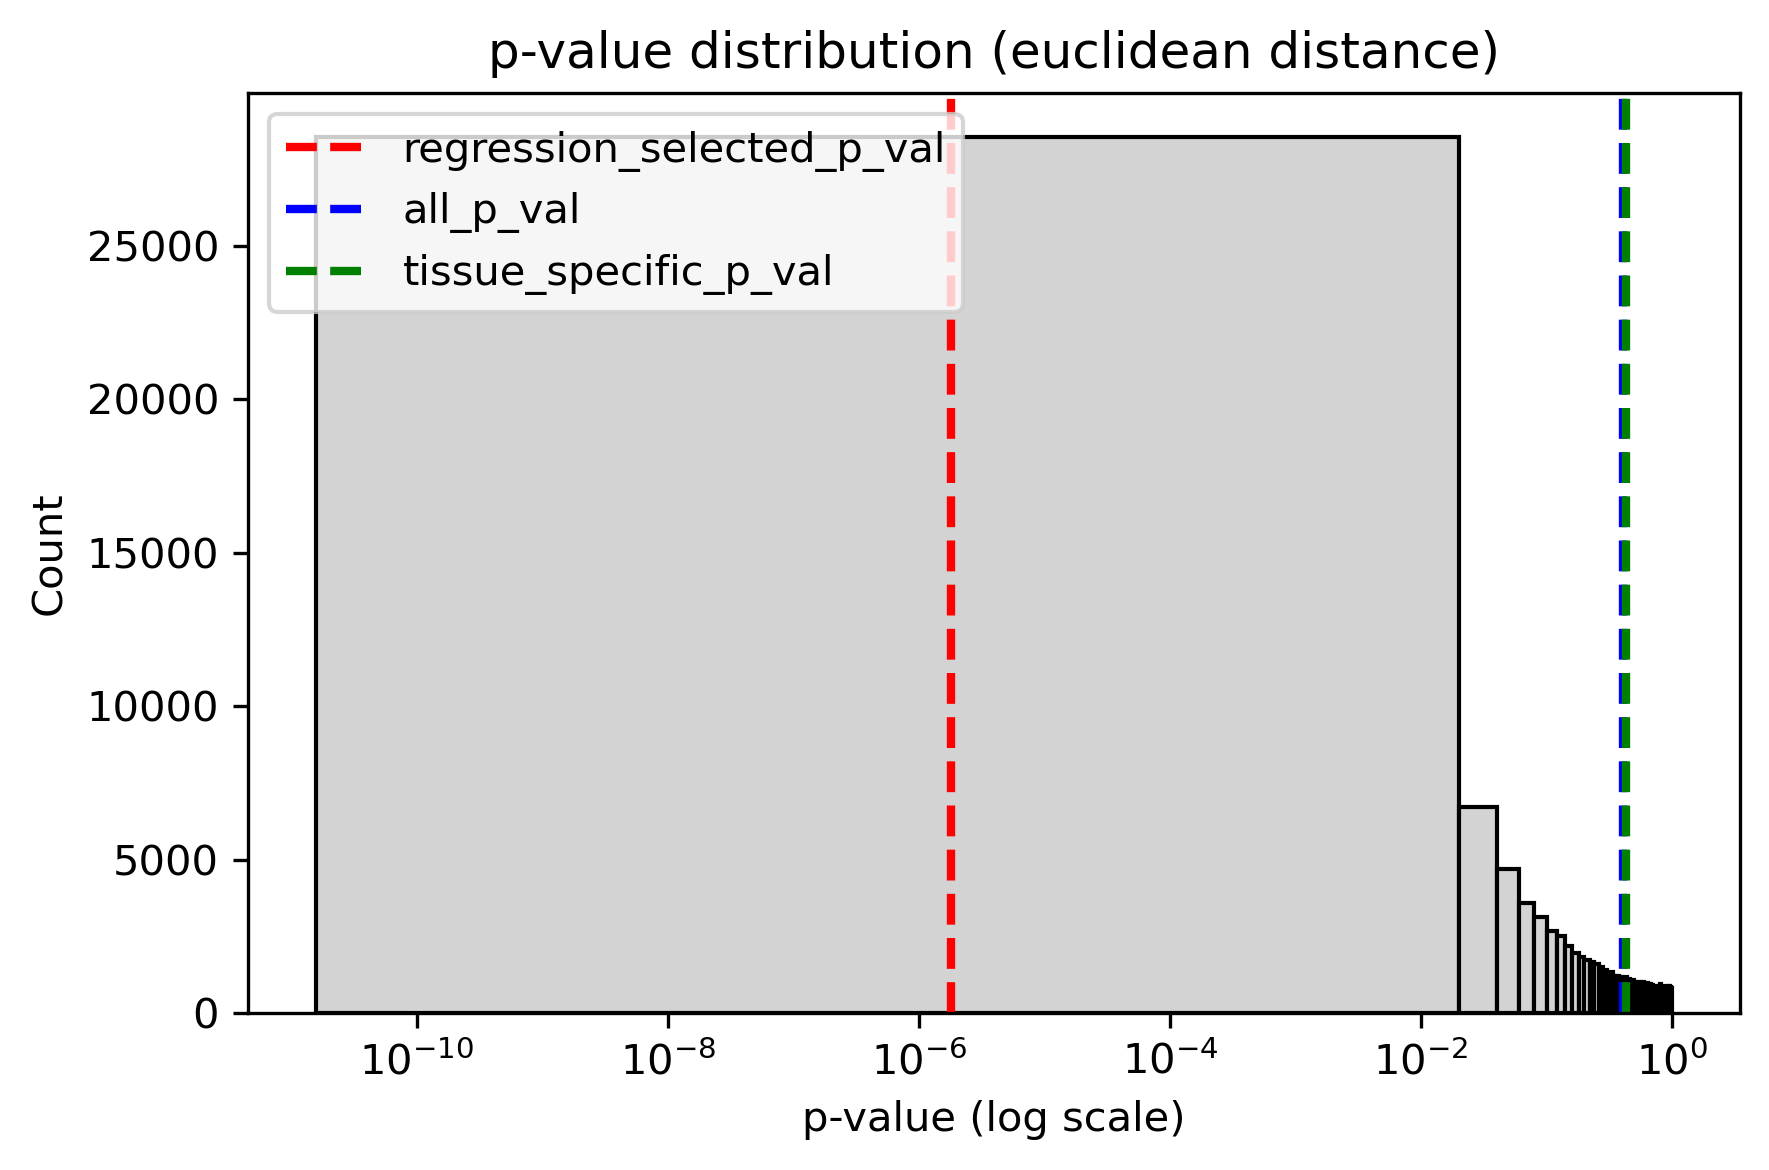

In [188]:
p_val_array = np.asarray(p_val_list, dtype=float)
selected_p_val = homo_hecter_distance_comp(selected_protein_exp)[1]
all_p_val = homo_hecter_distance_comp(protein_exp)[1]
tissue_p_val = homo_hecter_distance_comp(tissue_specific_exp)[1]
positive_p_vals = p_val_array[p_val_array > 0]
min_positive = positive_p_vals.min() if positive_p_vals.size > 0 else 1e-300
plot_p_vals = np.clip(p_val_array, min_positive, None)
plot_selected_p_val = max(float(selected_p_val), min_positive)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(plot_p_vals, bins=50, color='lightgray', edgecolor='black')
ax.axvline(plot_selected_p_val, color='red', linestyle='--', linewidth=2, label='regression_selected_p_val')
ax.axvline(all_p_val, color='blue', linestyle='--', linewidth=2, label='all_p_val')
ax.axvline(tissue_p_val, color='green', linestyle='--', linewidth=2, label='tissue_specific_p_val')
ax.set_xscale('log')
ax.set_xlabel('p-value (log scale)')
ax.set_ylabel('Count')
ax.set_title('p-value distribution (euclidean distance)')
ax.legend()
plt.tight_layout()
plt.show()


In [185]:
cos_p_val_list = []

for i in tqdm(range(100000)):
    np.random.seed(i)
    # randomly pick 20 proteins from protein expression data to calculate distances
    selected_proteins = np.random.choice(protein_exp.columns, size=20, replace=False)
    selected_df = protein_exp[selected_proteins]
    cos_p_val_list.append(homo_hecter_distance_comp(selected_df, distance_func=cosine)[1])


100%|██████████| 100000/100000 [06:30<00:00, 255.96it/s]


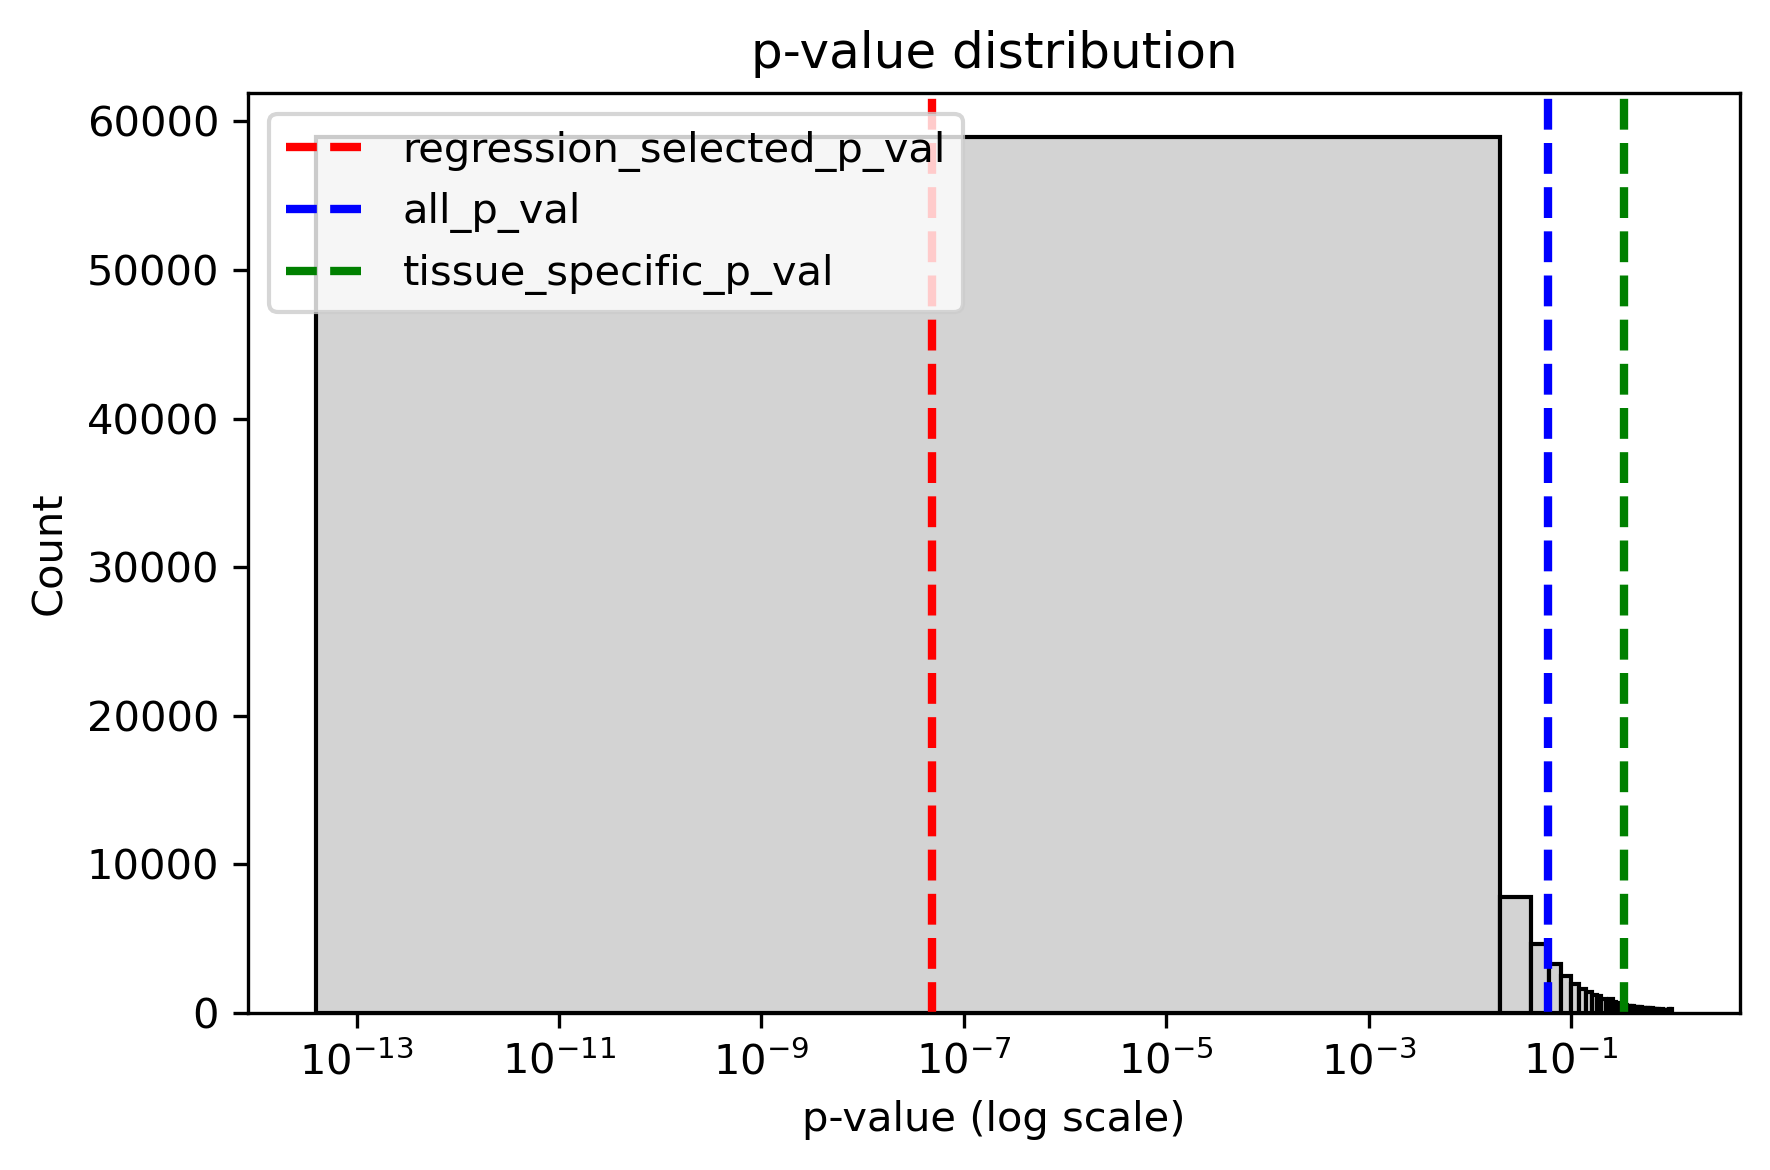

In [ ]:
p_val_array = np.asarray(cos_p_val_list, dtype=float)
selected_p_val = homo_hecter_distance_comp(selected_protein_exp, distance_func=cosine)[1]
all_p_val = homo_hecter_distance_comp(protein_exp, distance_func=cosine)[1]
tissue_p_val = homo_hecter_distance_comp(tissue_specific_exp, distance_func=cosine)[1]
positive_p_vals = p_val_array[p_val_array > 0]
min_positive = positive_p_vals.min() if positive_p_vals.size > 0 else 1e-300
plot_p_vals = np.clip(p_val_array, min_positive, None)
plot_selected_p_val = max(float(selected_p_val), min_positive)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(plot_p_vals, bins=50, color='lightgray', edgecolor='black')
ax.axvline(plot_selected_p_val, color='red', linestyle='--', linewidth=2, label='regression_selected_p_val')
ax.axvline(all_p_val, color='blue', linestyle='--', linewidth=2, label='all_p_val')
ax.axvline(tissue_p_val, color='green', linestyle='--', linewidth=2, label='tissue_specific_p_val')
ax.set_xscale('log')
ax.set_xlabel('p-value (log scale)')
ax.set_ylabel('Count')
ax.set_title('p-value distribution (cosine distance)')
ax.legend()
plt.tight_layout()
plt.show()

In [116]:
def pareto_exp_comp(xyz_cost_mat, exp_cost_mat_1, exp_cost_mat_2, exp_name_1, exp_name_2):
    pareto_xyz_costs = []
    pareto_exp_1_costs = []
    pareto_exp_2_costs = []
    lineage_xyz_cost = xyz_cost_mat.diagonal().sum()
    lineage_exp_1_cost = exp_cost_mat_1.diagonal().sum()
    lineage_exp_2_cost = exp_cost_mat_2.diagonal().sum()
    col_ind_list = []
    for i in tqdm(range(1001)):
        alpha = i / 1000.0
        combined_cost_mat = alpha * exp_cost_mat_1 + (1 - alpha) * xyz_cost_mat
        row_ind, col_ind = linear_sum_assignment(combined_cost_mat)
        col_ind_list.append(col_ind)
        pareto_xyz_costs.append(xyz_cost_mat[row_ind, col_ind].sum())
        pareto_exp_1_costs.append(exp_cost_mat_1[row_ind, col_ind].sum())
        pareto_exp_2_costs.append(exp_cost_mat_2[row_ind, col_ind].sum())
    print(len(np.unique(pareto_exp_1_costs)), len(np.unique(pareto_exp_2_costs)), len(np.unique(col_ind_list, axis=0)))
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 10), sharex=True)
    fig.suptitle("pareto comparison between" + exp_name_1 + " and " + exp_name_2)
    ax1.plot(pareto_xyz_costs, pareto_exp_1_costs, marker='o', linestyle='-', color='black', markersize=3, label='Pareto Front in Protein Expression Space')
    ax1.scatter(lineage_xyz_cost, lineage_exp_1_cost, marker='*', color='#FF0000', label='Real Lineage Cost')
    ax1.set_ylabel(exp_name_1 + " Cost")
    ax1.set_xlabel('Motility Cost')
    ax2.plot(pareto_xyz_costs, pareto_exp_2_costs, marker='o', linestyle='-', color='black', markersize=3, label='Pareto Front in ScRNA Expression Space')
    ax2.scatter(lineage_xyz_cost, lineage_exp_2_cost, marker='*', color='#FF0000', label='Real Lineage Cost')
    ax2.set_ylabel(exp_name_2 + " Cost")
    ax2.set_xlabel('Motility Cost')
    plt.tight_layout()
    plt.show()
    return col_ind_list

In [ ]:
for i, random_exp_cost_mat in enumerate(random_exp_cost_mats[:5]):
    pareto_exp_comp(xyz_cost_mat, exp_cost_mat, random_exp_cost_mat,"All Protein Exp", f"Random Exp {i}")

100%|██████████| 1001/1001 [00:03<00:00, 257.79it/s]


161 165 1001


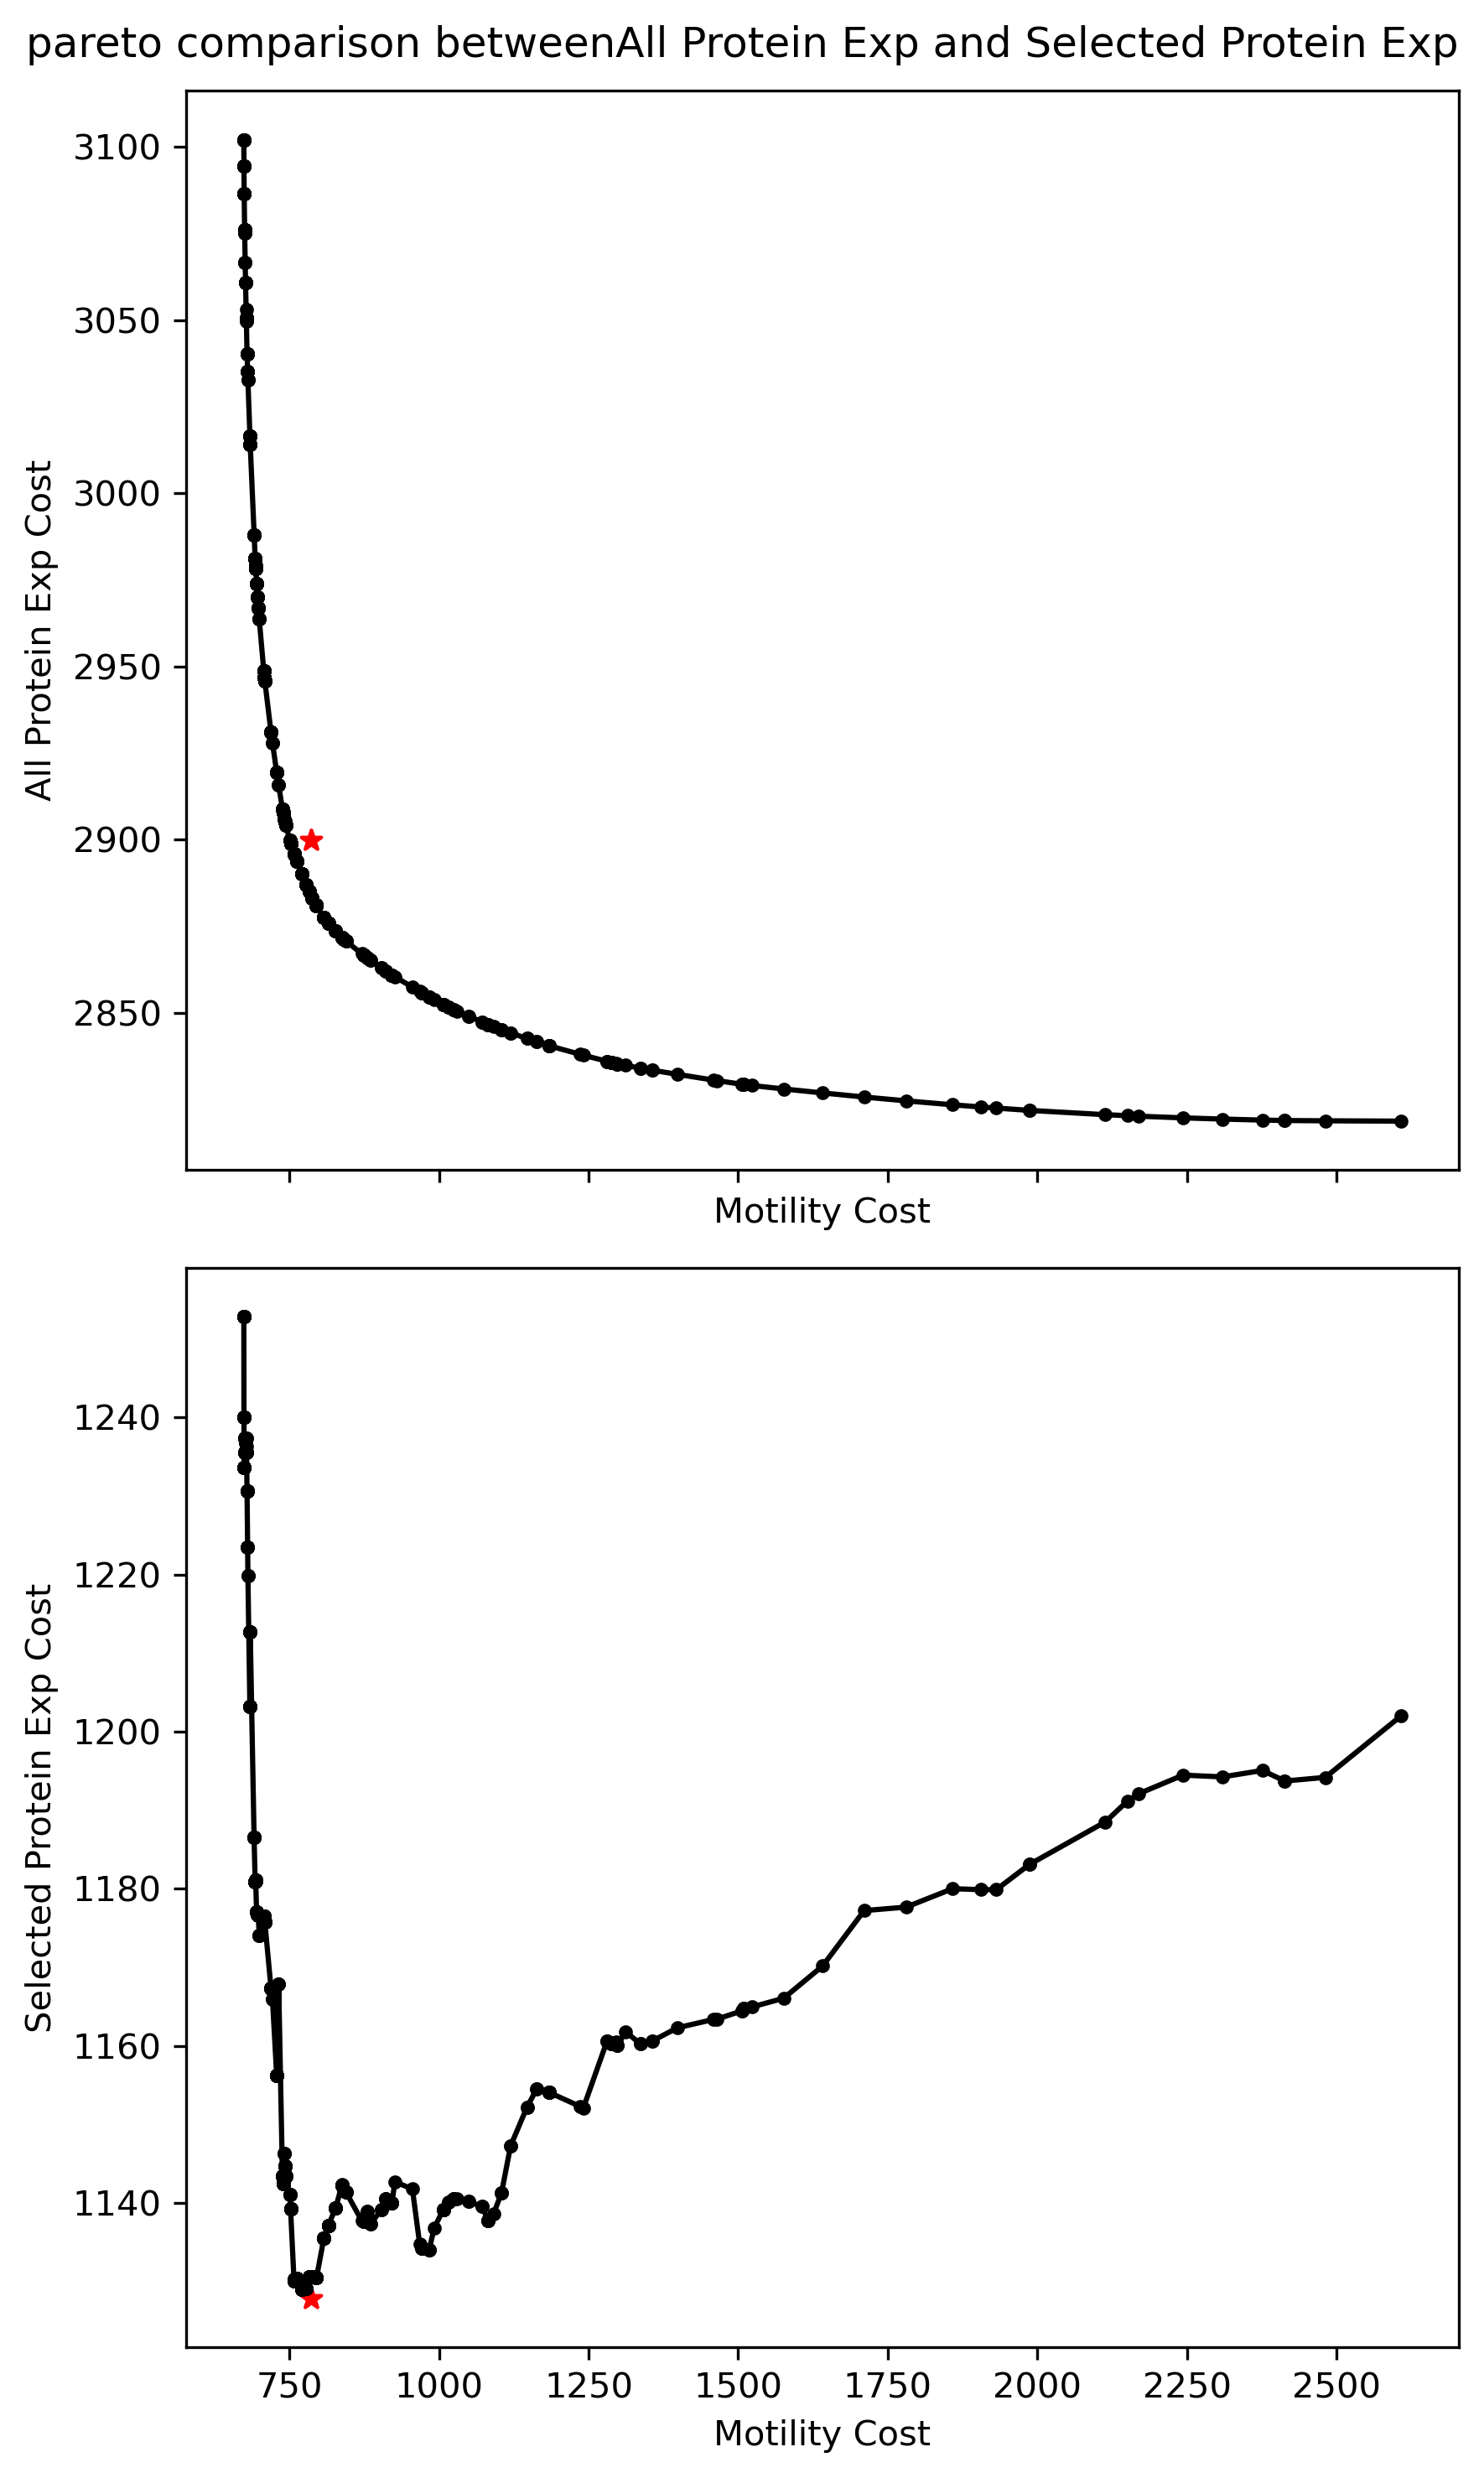

In [119]:
res = pareto_exp_comp(xyz_cost_mat, tissue_specific_exp_cost_mat, alt_exp_cost_mat, "All Protein Exp", "Selected Protein Exp")

In [50]:
new_pf = ParetoFront(terminal_nodes, terminal_parents, terminal_ancestry, xyz_coord_dict, lineage_exp, binary_lineage_exp, binary_lineage_end_exp, title="Pareto Front of 299 Terminal Cells")

In [51]:
xyz_mat, exp_mat = new_pf.compute_cost_matrices()
res = new_pf.compute_pareto_front(xyz_mat, exp_mat, monte_carlo=False, return_lca_distances=True)

100%|██████████| 189/189 [00:00<00:00, 611.20it/s]


0.965 475.76746082489444


In [ ]:
res = new_pf.pre_plot()